# 📊 Notebook 01 — Exploration des Données (EDA)
## Stage : Détection de Fraude Bancaire avec Federated Learning & Agentic AI

**Objectifs de ce notebook :**
- Charger et explorer les deux datasets (ULB + Synthétique)
- Analyser le déséquilibre des classes
- Visualiser les distributions des features
- Comprendre la structure des données avant modélisation


In [10]:
import sys, os

# Chemin local — mettez vos CSV ici
BASE_PATH = "../data/"
print("💻 Mode local — datasets attendus dans :", os.path.abspath(BASE_PATH))
print(f"BASE_PATH = {BASE_PATH}")


💻 Mode local — datasets attendus dans : c:\Users\aminf\Desktop\Stage\FraudDetection_Stage\data
BASE_PATH = ../data/


In [11]:
# Installation des dépendances
print("💻 En local — vérifiez requirements.txt")


💻 En local — vérifiez requirements.txt


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Style global des graphiques
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

print("📚 Bibliothèques chargées.")


📚 Bibliothèques chargées.


## 1. Chargement du Dataset ULB (Credit Card Fraud Detection)

In [13]:
ULB_PATH = os.path.join(BASE_PATH, "creditcard.csv")

try:
    df_ulb = pd.read_csv(ULB_PATH)
    print(f"✅ Dataset ULB chargé : {df_ulb.shape[0]:,} lignes × {df_ulb.shape[1]} colonnes")
    print(f"\n📋 Aperçu :")
    display(df_ulb.head())
    print(f"\n📊 Statistiques :")
    display(df_ulb.describe())
except FileNotFoundError:
    print(f"❌ Fichier non trouvé : {ULB_PATH}")
    print("   → Placez creditcard.csv dans votre BASE_PATH")
    df_ulb = None


✅ Dataset ULB chargé : 284,807 lignes × 31 colonnes

📋 Aperçu :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



📊 Statistiques :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 2. Analyse du Déséquilibre des Classes

══════════════════════════════════════════════════
  RÉPARTITION DES CLASSES — Dataset ULB
══════════════════════════════════════════════════
  Légitimes (0) : 284,315  (99.827%)
  Fraudes   (1) : 492   (0.173%)
  Ratio d'imbalance : 1:577
══════════════════════════════════════════════════


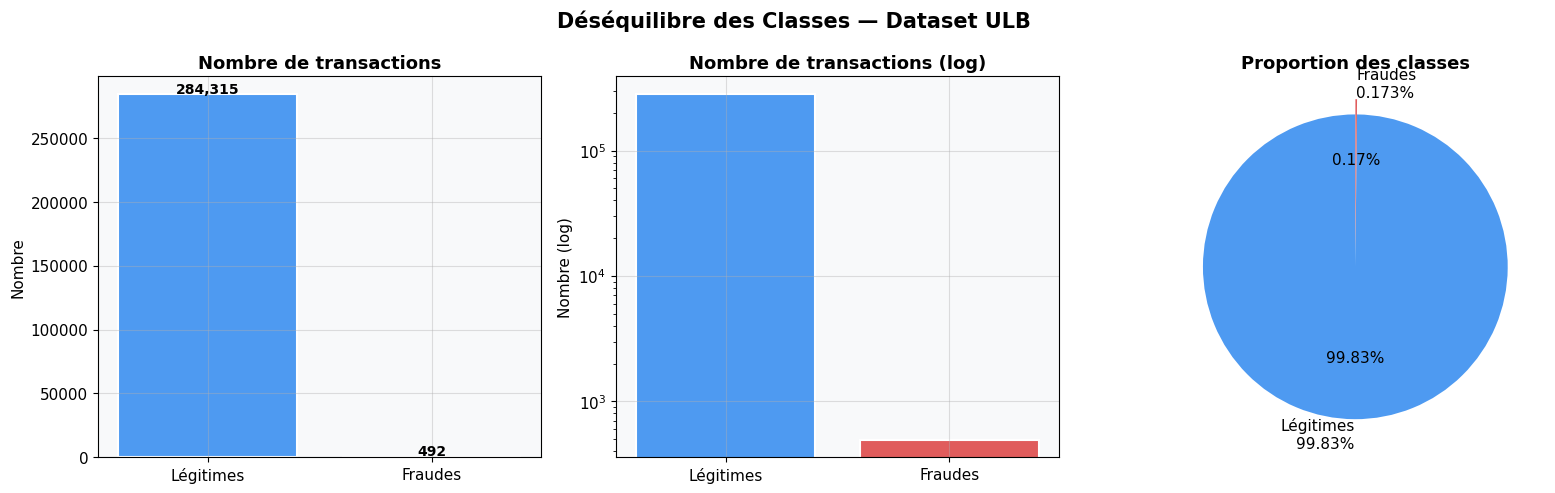


⚠️  Un modèle naïf 'tout légitime' obtient 99.83% de précision → INUTILISABLE !


In [14]:
if df_ulb is not None:
    counts = df_ulb['Class'].value_counts()
    total  = len(df_ulb)

    print("═" * 50)
    print("  RÉPARTITION DES CLASSES — Dataset ULB")
    print("═" * 50)
    print(f"  Légitimes (0) : {counts[0]:,}  ({counts[0]/total*100:.3f}%)")
    print(f"  Fraudes   (1) : {counts[1]:,}   ({counts[1]/total*100:.3f}%)")
    print(f"  Ratio d'imbalance : 1:{counts[0]//counts[1]}")
    print("═" * 50)

    # ── Visualisation 3-en-1 ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Déséquilibre des Classes — Dataset ULB", fontsize=15, fontweight='bold')

    colors = ['#4e9af1', '#e05c5c']

    # Bar chart
    bars = axes[0].bar(['Légitimes', 'Fraudes'], counts.values, color=colors,
                        edgecolor='white', linewidth=1.5)
    axes[0].set_title('Nombre de transactions')
    axes[0].set_ylabel('Nombre')
    for bar, val in zip(bars, counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                     f'{val:,}', ha='center', fontsize=10, fontweight='bold')

    # Bar chart (log scale)
    axes[1].bar(['Légitimes', 'Fraudes'], counts.values, color=colors,
                 edgecolor='white', linewidth=1.5)
    axes[1].set_yscale('log')
    axes[1].set_title('Nombre de transactions (log)')
    axes[1].set_ylabel('Nombre (log)')

    # Pie chart
    axes[2].pie(counts.values,
                labels=[f'Légitimes\n{counts[0]/total*100:.2f}%',
                        f'Fraudes\n{counts[1]/total*100:.3f}%'],
                colors=colors, autopct='%1.2f%%', startangle=90,
                explode=(0, 0.1))
    axes[2].set_title('Proportion des classes')

    plt.tight_layout()
    plt.show()
    print("\n⚠️  Un modèle naïf 'tout légitime' obtient {:.2f}% de précision → INUTILISABLE !".format(
        counts[0]/total*100))


## 3. Distribution des Features

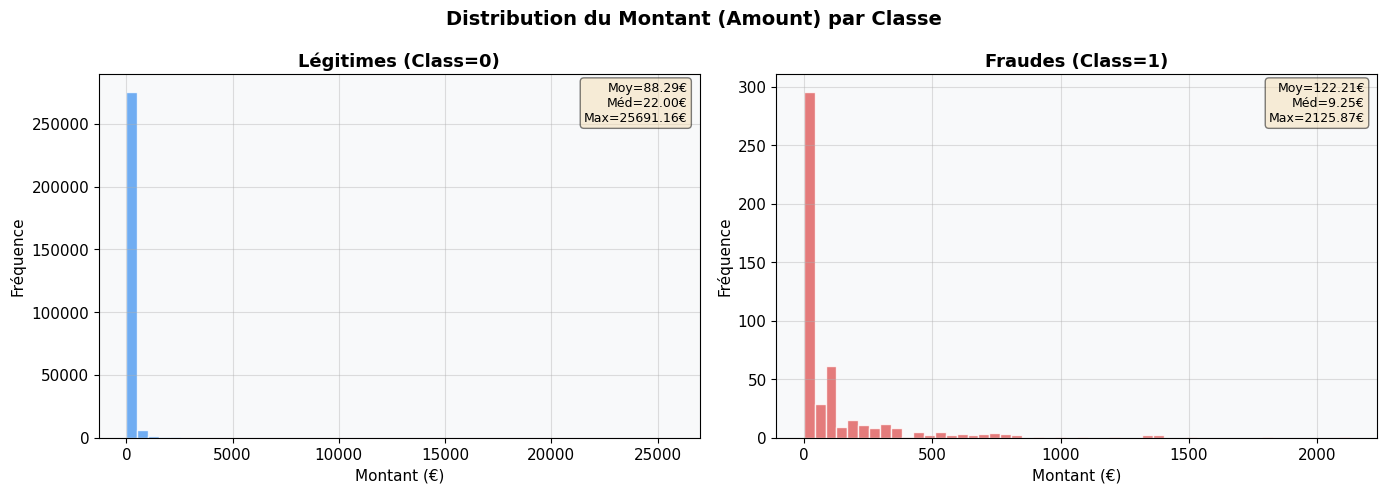

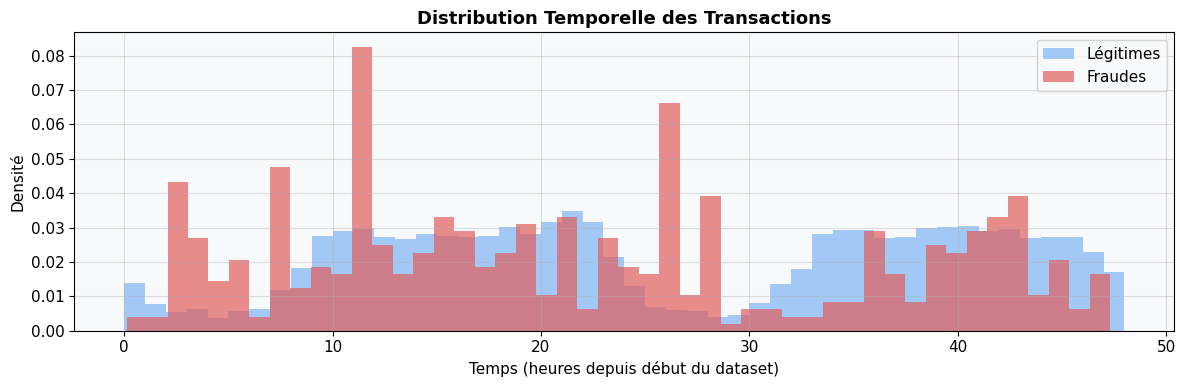

In [15]:
if df_ulb is not None:
    # Distribution de Amount
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Distribution du Montant (Amount) par Classe", fontsize=14, fontweight='bold')

    for ax, (label, color) in zip(axes, [(0, '#4e9af1'), (1, '#e05c5c')]):
        data = df_ulb[df_ulb['Class']==label]['Amount']
        ax.hist(data, bins=50, color=color, alpha=0.8, edgecolor='white')
        ax.set_title(f"{'Légitimes' if label==0 else 'Fraudes'} (Class={label})")
        ax.set_xlabel("Montant (€)")
        ax.set_ylabel("Fréquence")
        stats = f"Moy={data.mean():.2f}€\nMéd={data.median():.2f}€\nMax={data.max():.2f}€"
        ax.text(0.98, 0.98, stats, transform=ax.transAxes,
                va='top', ha='right', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout()
    plt.show()

    # Distribution de Time
    fig, ax = plt.subplots(figsize=(12, 4))
    fraud_time = df_ulb[df_ulb['Class']==1]['Time'] / 3600
    legit_time = df_ulb[df_ulb['Class']==0]['Time'] / 3600
    ax.hist(legit_time, bins=48, alpha=0.5, label='Légitimes', color='#4e9af1', density=True)
    ax.hist(fraud_time, bins=48, alpha=0.7, label='Fraudes',   color='#e05c5c', density=True)
    ax.set_xlabel("Temps (heures depuis début du dataset)")
    ax.set_ylabel("Densité")
    ax.set_title("Distribution Temporelle des Transactions")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 4. Corrélations des Features PCA avec la Classe

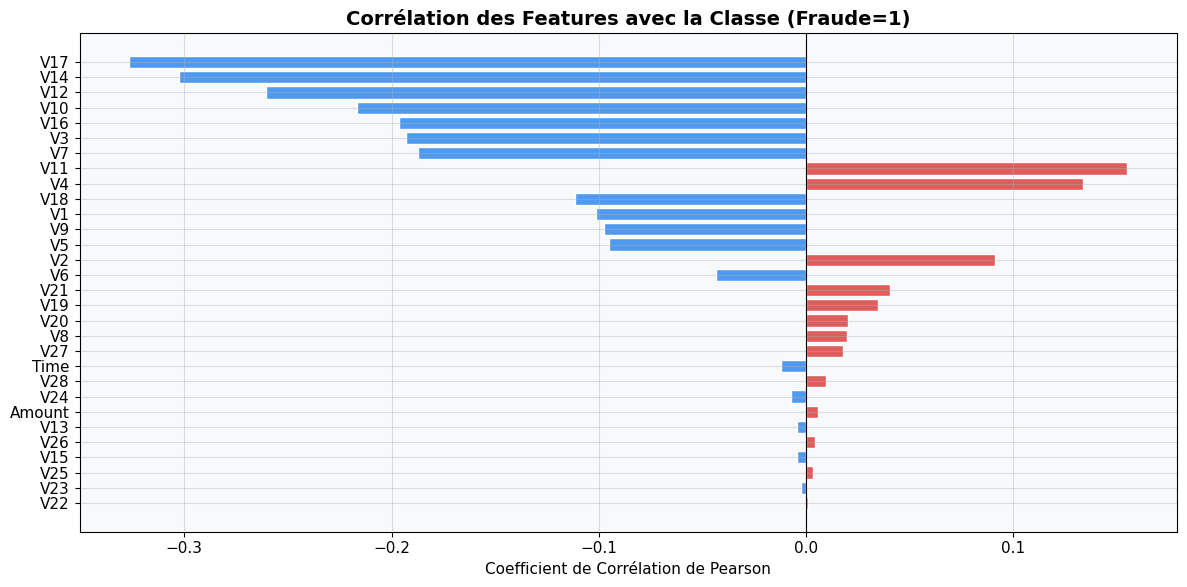

📌 Features les plus corrélées avec la fraude:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485

📌 Features les moins corrélées:
V26    0.004455
V15   -0.004223
V25    0.003308
V23   -0.002685
V22    0.000805


In [16]:
if df_ulb is not None:
    # Corrélation de chaque feature avec la classe
    corr_with_class = df_ulb.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['#e05c5c' if c > 0 else '#4e9af1' for c in corr_with_class.values]
    bars = ax.barh(corr_with_class.index, corr_with_class.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title("Corrélation des Features avec la Classe (Fraude=1)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Coefficient de Corrélation de Pearson")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("📌 Features les plus corrélées avec la fraude:")
    print(corr_with_class.head(10).to_string())
    print("\n📌 Features les moins corrélées:")
    print(corr_with_class.tail(5).to_string())


## 5. Chargement du Dataset Synthétique

In [17]:
SYNTH_PATH = os.path.join(BASE_PATH, "fraud_detection_credit_card_small.csv")

try:
    df_synth = pd.read_csv(SYNTH_PATH)
    print(f"✅ Dataset Synthétique chargé : {df_synth.shape[0]:,} lignes × {df_synth.shape[1]} colonnes")
    target_col = 'is_fraud' if 'is_fraud' in df_synth.columns else df_synth.columns[-1]
    counts_s = df_synth[target_col].value_counts()
    print(f"   Légitimes : {counts_s[0]:,}  |  Fraudes : {counts_s.get(1, 0):,}")
    display(df_synth.head(3))
    print("\n📋 Colonnes disponibles :")
    print(list(df_synth.columns))
except FileNotFoundError:
    print(f"❌ Dataset synthétique non trouvé : {SYNTH_PATH}")
    df_synth = None


✅ Dataset Synthétique chargé : 100,000 lignes × 31 colonnes
   Légitimes : 99,402  |  Fraudes : 598


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned
0,1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,...,-78.865012,0,15909.0,Electronics,In-store,6,11:10,69,Debit Card,332
1,547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,...,-123.636337,0,NaN,Entertainment,Online,8,20:42,47,Mobile Payment,476
2,110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,...,-78.898190,0,15961.0,Restaurants,Online,3,05:19,69,Debit Card,100



📋 Colonnes disponibles :
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode', 'Merchant_Category', 'Transaction_Type', 'Customer_Satisfaction_Score', 'Transaction_Time', 'Customer_Age', 'Payment_Method', 'Loyalty_Points_Earned']


## 6. Comparaison des Deux Datasets

In [18]:
print("╔══════════════════════════════════════════════════════════╗")
print("║         COMPARAISON DES DEUX DATASETS                   ║")
print("╠══════════════════════════════════════════════════════════╣")

if df_ulb is not None:
    print(f"║  ULB (réel, anonymisé)    : {df_ulb.shape[0]:>9,} transactions  ║")
    print(f"║    Features               : {df_ulb.shape[1]:>9} colonnes       ║")
    print(f"║    Taux de fraude         : {df_ulb['Class'].mean()*100:>9.3f}%           ║")
else:
    print("║  ULB : non chargé                                       ║")

if df_synth is not None:
    print(f"║  Synthétique              : {df_synth.shape[0]:>9,} transactions  ║")
    print(f"║    Features               : {df_synth.shape[1]:>9} colonnes       ║")
    tgt = 'is_fraud' if 'is_fraud' in df_synth.columns else df_synth.columns[-1]
    print(f"║    Taux de fraude         : {df_synth[tgt].mean()*100:>9.3f}%           ║")
else:
    print("║  Synthétique : non chargé                               ║")

print("╚══════════════════════════════════════════════════════════╝")
print("\n📌 Usage recommandé:")
print("   • ULB       → Entraînement ML/DL (Section 4.2, 4.4)")
print("   • Synthétique → Démonstration agent LLM (Section 4.5, explications lisibles)")


╔══════════════════════════════════════════════════════════╗
║         COMPARAISON DES DEUX DATASETS                   ║
╠══════════════════════════════════════════════════════════╣
║  ULB (réel, anonymisé)    :   284,807 transactions  ║
║    Features               :        31 colonnes       ║
║    Taux de fraude         :     0.173%           ║
║  Synthétique              :   100,000 transactions  ║
║    Features               :        31 colonnes       ║
║    Taux de fraude         :     0.598%           ║
╚══════════════════════════════════════════════════════════╝

📌 Usage recommandé:
   • ULB       → Entraînement ML/DL (Section 4.2, 4.4)
   • Synthétique → Démonstration agent LLM (Section 4.5, explications lisibles)


## ✅ Résumé du Notebook 01
- Deux datasets chargés et explorés
- Déséquilibre des classes analysé
- Corrélations features/fraude visualisées
- Datasets complémentaires selon l'usage